# Lab 3: Simple Linear Regression
**Course:** Machine Learning

**Objective:** Perform Simple Linear Regression using Scikit-learn and manually using OLS formulas to check if CIA % and Attendance % can predict GPA.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



---
## Part A: Data Collection and Preprocessing

### Step 2: Load the Dataset

In [2]:
df = pd.read_csv('Student Awareness Survey (Responses) - Form Responses 1.csv')

df.columns = [
    'Timestamp', 'Reg_No', 'Email', 'Job_Role',
    'Min_Salary', 'Max_Salary', 'Median_Salary', 'Highest_Paying_Company',
    'Extra_Curricular', 'Technical_Competency', 'Package_Expectation',
    'CIA_Percent', 'GPA', 'Attendance_Percent', 'Internship_Interest'
]

print("Dataset loaded")
print("Shape:", df.shape)

Dataset loaded
Shape: (50, 15)


### Step 3: Display First 5 Rows

In [3]:
df.head()

,Timestamp,Reg_No,Email,Job_Role,Min_Salary,Max_Salary,Median_Salary,Highest_Paying_Company,Extra_Curricular,Technical_Competency,Package_Expectation,CIA_Percent,GPA,Attendance_Percent,Internship_Interest
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


### Step 4: Check Dataset Dimensions

In [4]:
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
print("\nColumn names:", list(df.columns))

Rows    : 50
Columns : 15

Column names: ['Timestamp', 'Reg_No', 'Email', 'Job_Role', 'Min_Salary', 'Max_Salary', 'Median_Salary', 'Highest_Paying_Company', 'Extra_Curricular', 'Technical_Competency', 'Package_Expectation', 'CIA_Percent', 'GPA', 'Attendance_Percent', 'Internship_Interest']


### Step 5: Identify Missing Values

In [5]:
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

Timestamp                 0
Reg_No                    0
Email                     0
Job_Role                  0
Min_Salary                0
Max_Salary                0
Median_Salary             0
Highest_Paying_Company    1
Extra_Curricular          1
Technical_Competency      1
Package_Expectation       1
CIA_Percent               0
GPA                       0
Attendance_Percent        0
Internship_Interest       1
dtype: int64

Total missing: 5


### Step 6: Convert Columns to Numeric

The survey responses have messy data - some values have % signs, LPA text, extra spaces, etc. We need to clean the CIA_Percent, GPA and Attendance_Percent columns before using them.

In [6]:
working_cols = ['Reg_No', 'CIA_Percent', 'GPA', 'Attendance_Percent']
df_clean = df[working_cols].copy()

print("Raw values before cleaning:")
print(df_clean.to_string())

Raw values before cleaning:
     Reg_No CIA_Percent   GPA Attendance_Percent
0   2547231          69  3.40                 98
1   2547237          75  3.69                 95
2   2547203          82  3.41                 95
3   2547228          91  3.60                 92
4   2547241          70  3.54                 93
5   2547233          75  3.67                 98
6   2547213          74  3.40                 94
7   2547240          68  3.40                 85
8   2547229          73  3.60                 90
9   2547234          79  3.73                 93
10  2547242          72  3.54                 95
11  2547224          80  3.00                 95
12  2547243          78  3.32                 95
13  2547247           7  8.00                85%
14  2547249          70  3.49                100
15  2547226          60  3.00                 85
16  2547239          68  3.14                 88
17  2547220        71 %  3.40               91 %
18  2547222          64  3.11            

In [7]:
def clean_numeric(series):
    return (
        series.astype(str)
             .str.replace('%', '', regex=False)
             .str.replace('LPA', '', regex=False, flags=__import__('re').IGNORECASE)
             .str.strip()
             .apply(pd.to_numeric, errors='coerce')
    )

df_clean['CIA_Percent']        = clean_numeric(df_clean['CIA_Percent'])
df_clean['GPA']                = clean_numeric(df_clean['GPA'])
df_clean['Attendance_Percent'] = clean_numeric(df_clean['Attendance_Percent'])

print("After cleaning:")
print(df_clean.to_string())

After cleaning:
     Reg_No  CIA_Percent   GPA  Attendance_Percent
0   2547231        69.00  3.40               98.00
1   2547237        75.00  3.69               95.00
2   2547203        82.00  3.41               95.00
3   2547228        91.00  3.60               92.00
4   2547241        70.00  3.54               93.00
5   2547233        75.00  3.67               98.00
6   2547213        74.00  3.40               94.00
7   2547240        68.00  3.40               85.00
8   2547229        73.00  3.60               90.00
9   2547234        79.00  3.73               93.00
10  2547242        72.00  3.54               95.00
11  2547224        80.00  3.00               95.00
12  2547243        78.00  3.32               95.00
13  2547247         7.00  8.00               85.00
14  2547249        70.00  3.49              100.00
15  2547226        60.00  3.00               85.00
16  2547239        68.00  3.14               88.00
17  2547220        71.00  3.40               91.00
18  2547222    

### Step 7: Remove Invalid Values

Expected valid ranges:
- CIA Percent: 0 to 100
- GPA: 0 to 4 (CHRIST University uses 4-point scale)
- Attendance Percent: 0 to 100

In [8]:
print("Rows with GPA outside 0-4:")
print(df_clean[~df_clean['GPA'].between(0, 4)])

print("\nRows with CIA % outside 0-100:")
print(df_clean[~df_clean['CIA_Percent'].between(0, 100)])

print("\nRows with Attendance % outside 0-100:")
print(df_clean[~df_clean['Attendance_Percent'].between(0, 100)])

Rows with GPA outside 0-4:
     Reg_No  CIA_Percent  GPA  Attendance_Percent
13  2547247          7.0  8.0                85.0

Rows with CIA % outside 0-100:
Empty DataFrame
Columns: [Reg_No, CIA_Percent, GPA, Attendance_Percent]
Index: []

Rows with Attendance % outside 0-100:
Empty DataFrame
Columns: [Reg_No, CIA_Percent, GPA, Attendance_Percent]
Index: []


In [9]:
mask = (
    df_clean['CIA_Percent'].between(0, 100) &
    df_clean['GPA'].between(0, 4) &
    df_clean['Attendance_Percent'].between(0, 100)
)

df_clean = df_clean[mask].reset_index(drop=True)
print("Rows remaining after removing invalid entries:", len(df_clean))

Rows remaining after removing invalid entries: 49


### Step 8: Remove Null Values

In [10]:
print("Missing values before:")
print(df_clean.isnull().sum())

df_clean.dropna(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print("\nMissing values after:")
print(df_clean.isnull().sum())
print("\nShape:", df_clean.shape)

Missing values before:
Reg_No                0
CIA_Percent           0
GPA                   0
Attendance_Percent    0
dtype: int64

Missing values after:
Reg_No                0
CIA_Percent           0
GPA                   0
Attendance_Percent    0
dtype: int64

Shape: (49, 4)


### Step 9: Remove Duplicate Records

In [11]:
print("Duplicate rows:", df_clean.duplicated().sum())
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows: 0
Shape after removing duplicates: (49, 4)


### Step 10: Statistical Summary

In [12]:
df_clean[['CIA_Percent', 'GPA', 'Attendance_Percent']].describe()

,CIA_Percent,GPA,Attendance_Percent
count,49.000000,49.000000,49.000000
mean,72.825102,3.405102,94.004898
std,6.378355,0.237023,3.674066
min,60.000000,2.740000,85.000000
25%,69.780000,3.300000,92.000000
50%,71.780000,3.400000,95.000000
75%,77.000000,3.600000,96.000000
max,91.000000,3.900000,100.000000


### Step 11: Select Dependent and Independent Variables

| Experiment | Independent Variable (X) | Dependent Variable (Y) |
|:---:|:---:|:---:|
| 1 | CIA Percentage | GPA |
| 2 | Attendance Percentage | GPA |

In [13]:
X1 = df_clean[['CIA_Percent']].values
Y1 = df_clean['GPA'].values

X2 = df_clean[['Attendance_Percent']].values
Y2 = df_clean['GPA'].values

print("Experiment 1 - X shape:", X1.shape, "Y shape:", Y1.shape)
print("Experiment 2 - X shape:", X2.shape, "Y shape:", Y2.shape)

Experiment 1 - X shape: (49, 1) Y shape: (49,)
Experiment 2 - X shape: (49, 1) Y shape: (49,)


### Step 12: Scatter Plots

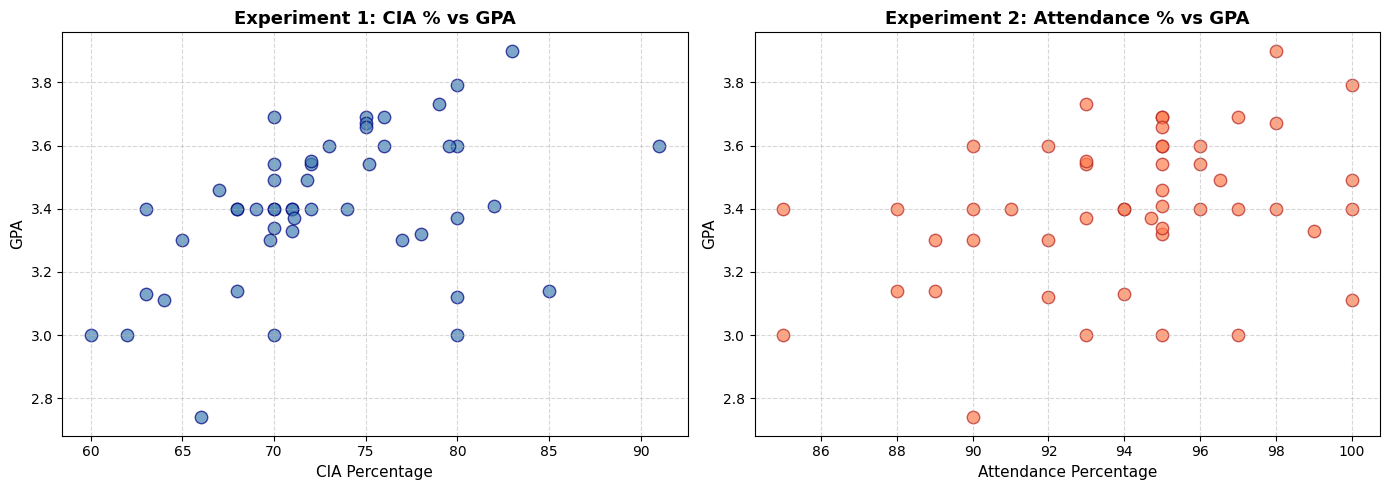

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_clean['CIA_Percent'], df_clean['GPA'],
                color='steelblue', edgecolors='navy', alpha=0.7, s=80)
axes[0].set_title('Experiment 1: CIA % vs GPA', fontsize=13, fontweight='bold')
axes[0].set_xlabel('CIA Percentage', fontsize=11)
axes[0].set_ylabel('GPA', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(df_clean['Attendance_Percent'], df_clean['GPA'],
                color='coral', edgecolors='firebrick', alpha=0.7, s=80)
axes[1].set_title('Experiment 2: Attendance % vs GPA', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attendance Percentage', fontsize=11)
axes[1].set_ylabel('GPA', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## Part B: Simple Linear Regression using Scikit-learn

The regression equation is:

$$\hat{y} = m \cdot x + b$$

where $m$ is the slope and $b$ is the intercept.

### Experiment 1 (Scikit-learn): CIA % to GPA

In [15]:
X1_train, X1_test, Y1_train, Y1_test = train_test_split(
    X1, Y1, test_size=0.2, random_state=42
)

print("Training samples:", len(X1_train))
print("Testing samples :", len(X1_test))

Training samples: 39
Testing samples : 10


In [16]:
model_sk1 = LinearRegression()
model_sk1.fit(X1_train, Y1_train)

slope_sk1     = model_sk1.coef_[0]
intercept_sk1 = model_sk1.intercept_

print("Experiment 1 - Scikit-learn")
print("Slope     :", round(slope_sk1, 6))
print("Intercept :", round(intercept_sk1, 6))
print("Equation  : GPA = {:.4f} * CIA% + {:.4f}".format(slope_sk1, intercept_sk1))

Experiment 1 - Scikit-learn
Slope     : 0.0128
Intercept : 2.48338
Equation  : GPA = 0.0128 * CIA% + 2.4834


In [17]:
Y1_pred_sk = model_sk1.predict(X1_test)

pred_df1 = pd.DataFrame({
    'CIA_Percent'     : X1_test.flatten(),
    'Actual_GPA'      : Y1_test,
    'Predicted_GPA_SK': np.round(Y1_pred_sk, 4)
})
print(pred_df1.to_string(index=False))

 CIA_Percent  Actual_GPA  Predicted_GPA_SK
        70.0        3.49            3.3794
        70.0        3.69            3.3794
        66.0        2.74            3.3282
        75.0        3.66            3.4434
        64.0        3.11            3.3026
        71.0        3.33            3.3922
        70.0        3.00            3.3794
        70.0        3.40            3.3794
        80.0        3.60            3.5074
        70.0        3.34            3.3794


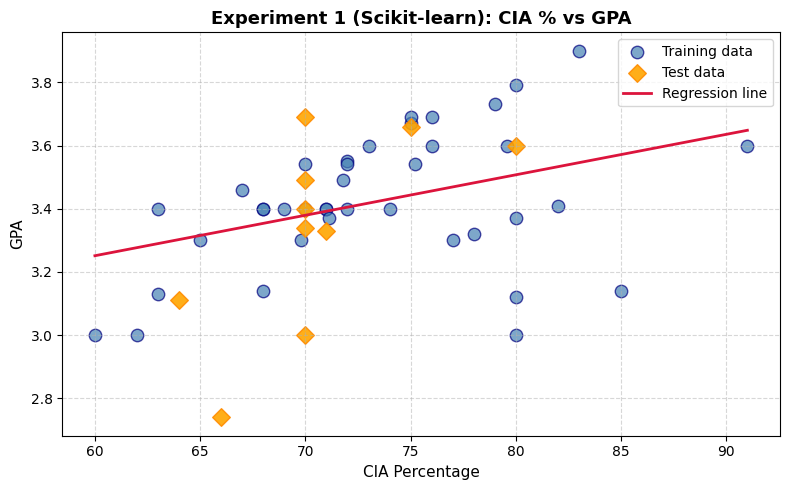

In [18]:
x_line1 = np.linspace(X1.min(), X1.max(), 200).reshape(-1, 1)
y_line1 = model_sk1.predict(x_line1)

plt.figure(figsize=(8, 5))
plt.scatter(X1_train, Y1_train, color='steelblue', label='Training data',
            edgecolors='navy', alpha=0.7, s=80)
plt.scatter(X1_test, Y1_test, color='orange', label='Test data',
            edgecolors='darkorange', alpha=0.9, s=80, marker='D')
plt.plot(x_line1, y_line1, color='crimson', linewidth=2, label='Regression line')
plt.title('Experiment 1 (Scikit-learn): CIA % vs GPA', fontsize=13, fontweight='bold')
plt.xlabel('CIA Percentage', fontsize=11)
plt.ylabel('GPA', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Experiment 2 (Scikit-learn): Attendance % to GPA

In [19]:
X2_train, X2_test, Y2_train, Y2_test = train_test_split(
    X2, Y2, test_size=0.2, random_state=42
)

print("Training samples:", len(X2_train))
print("Testing samples :", len(X2_test))

Training samples: 39
Testing samples : 10


In [20]:
model_sk2 = LinearRegression()
model_sk2.fit(X2_train, Y2_train)

slope_sk2     = model_sk2.coef_[0]
intercept_sk2 = model_sk2.intercept_

print("Experiment 2 - Scikit-learn")
print("Slope     :", round(slope_sk2, 6))
print("Intercept :", round(intercept_sk2, 6))
print("Equation  : GPA = {:.4f} * Att% + {:.4f}".format(slope_sk2, intercept_sk2))

Experiment 2 - Scikit-learn
Slope     : 0.02441
Intercept : 1.140655
Equation  : GPA = 0.0244 * Att% + 1.1407


In [21]:
Y2_pred_sk = model_sk2.predict(X2_test)

pred_df2 = pd.DataFrame({
    'Attendance_Percent' : X2_test.flatten(),
    'Actual_GPA'         : Y2_test,
    'Predicted_GPA_SK'   : np.round(Y2_pred_sk, 4)
})
print(pred_df2.to_string(index=False))

 Attendance_Percent  Actual_GPA  Predicted_GPA_SK
              100.0        3.49            3.5816
               97.0        3.69            3.5084
               90.0        2.74            3.3375
               95.0        3.66            3.4596
              100.0        3.11            3.5816
               99.0        3.33            3.5572
               93.0        3.00            3.4108
               96.0        3.40            3.4840
               95.0        3.60            3.4596
               95.0        3.34            3.4596


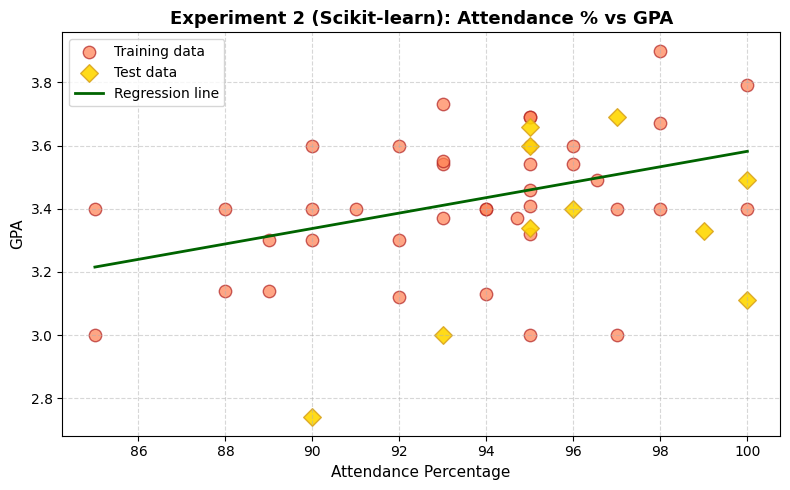

In [22]:
x_line2 = np.linspace(X2.min(), X2.max(), 200).reshape(-1, 1)
y_line2 = model_sk2.predict(x_line2)

plt.figure(figsize=(8, 5))
plt.scatter(X2_train, Y2_train, color='coral', label='Training data',
            edgecolors='firebrick', alpha=0.7, s=80)
plt.scatter(X2_test, Y2_test, color='gold', label='Test data',
            edgecolors='goldenrod', alpha=0.9, s=80, marker='D')
plt.plot(x_line2, y_line2, color='darkgreen', linewidth=2, label='Regression line')
plt.title('Experiment 2 (Scikit-learn): Attendance % vs GPA', fontsize=13, fontweight='bold')
plt.xlabel('Attendance Percentage', fontsize=11)
plt.ylabel('GPA', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Part C: Manual Computation using Ordinary Least Squares (OLS)

The OLS formulas to compute slope and intercept are:

$$m = \frac{n \sum(x_i y_i) - \sum x_i \sum y_i}{n \sum x_i^2 - (\sum x_i)^2}$$

$$b = \bar{y} - m \cdot \bar{x}$$

The same training data used in Scikit-learn is used here to keep the comparison fair.

In [23]:
def ols_regression(x_train, y_train, x_test):
    n = len(x_train)
    numerator   = n * np.sum(x_train * y_train) - np.sum(x_train) * np.sum(y_train)
    denominator = n * np.sum(x_train ** 2) - (np.sum(x_train)) ** 2
    slope       = numerator / denominator
    intercept   = np.mean(y_train) - slope * np.mean(x_train)
    predictions = slope * x_test + intercept
    return slope, intercept, predictions

### Experiment 1 (OLS): CIA % to GPA

In [24]:
x1_train_flat = X1_train.flatten()
x1_test_flat  = X1_test.flatten()

slope_ols1, intercept_ols1, Y1_pred_ols = ols_regression(
    x1_train_flat, Y1_train, x1_test_flat
)

print("Experiment 1 - Manual OLS")
print("n            :", len(x1_train_flat))
print("Sum(x)       :", round(np.sum(x1_train_flat), 4))
print("Sum(y)       :", round(np.sum(Y1_train), 4))
print("Sum(x^2)     :", round(np.sum(x1_train_flat**2), 4))
print("Sum(xy)      :", round(np.sum(x1_train_flat * Y1_train), 4))
print("Mean(x)      :", round(np.mean(x1_train_flat), 4))
print("Mean(y)      :", round(np.mean(Y1_train), 4))
print("Slope        :", round(slope_ols1, 6))
print("Intercept    :", round(intercept_ols1, 6))
print("Equation     : GPA = {:.4f} * CIA% + {:.4f}".format(slope_ols1, intercept_ols1))

Experiment 1 - Manual OLS
n            : 39
Sum(x)       : 2862.43
Sum(y)       : 133.49
Sum(x^2)     : 211806.0825
Sum(xy)      : 9819.5509
Mean(x)      : 73.3956
Mean(y)      : 3.4228
Slope        : 0.0128
Intercept    : 2.48338
Equation     : GPA = 0.0128 * CIA% + 2.4834


### Experiment 2 (OLS): Attendance % to GPA

In [25]:
x2_train_flat = X2_train.flatten()
x2_test_flat  = X2_test.flatten()

slope_ols2, intercept_ols2, Y2_pred_ols = ols_regression(
    x2_train_flat, Y2_train, x2_test_flat
)

print("Experiment 2 - Manual OLS")
print("n            :", len(x2_train_flat))
print("Sum(x)       :", round(np.sum(x2_train_flat), 4))
print("Sum(y)       :", round(np.sum(Y2_train), 4))
print("Sum(x^2)     :", round(np.sum(x2_train_flat**2), 4))
print("Sum(xy)      :", round(np.sum(x2_train_flat * Y2_train), 4))
print("Mean(x)      :", round(np.mean(x2_train_flat), 4))
print("Mean(y)      :", round(np.mean(Y2_train), 4))
print("Slope        :", round(slope_ols2, 6))
print("Intercept    :", round(intercept_ols2, 6))
print("Equation     : GPA = {:.4f} * Att% + {:.4f}".format(slope_ols2, intercept_ols2))

Experiment 2 - Manual OLS
n            : 39
Sum(x)       : 3646.24
Sum(y)       : 133.49
Sum(x^2)     : 341407.0616
Sum(xy)      : 12492.8236
Mean(x)      : 93.4933
Mean(y)      : 3.4228
Slope        : 0.02441
Intercept    : 1.140655
Equation     : GPA = 0.0244 * Att% + 1.1407


---
## Comparison Task: Scikit-learn vs Manual OLS

Comparing:
1. Slope and intercept from both methods
2. Predictions on the test set
3. Difference between predictions

### Comparison - Experiment 1 (CIA % to GPA)

In [26]:
print("Parameter Comparison - Experiment 1")
print("{:<15} {:>15} {:>15}".format("Parameter", "Scikit-learn", "Manual OLS"))
print("-" * 48)
print("{:<15} {:>15.6f} {:>15.6f}".format("Slope", slope_sk1, slope_ols1))
print("{:<15} {:>15.6f} {:>15.6f}".format("Intercept", intercept_sk1, intercept_ols1))

Parameter Comparison - Experiment 1
Parameter          Scikit-learn      Manual OLS
------------------------------------------------
Slope                  0.012800        0.012800
Intercept              2.483380        2.483380


In [27]:
comp_df1 = pd.DataFrame({
    'CIA_Percent' : x1_test_flat,
    'Actual_GPA'  : Y1_test,
    'Pred_SK'     : np.round(Y1_pred_sk, 6),
    'Pred_OLS'    : np.round(Y1_pred_ols, 6),
    'Difference'  : np.round(np.abs(Y1_pred_sk - Y1_pred_ols), 10)
})
print(comp_df1.to_string(index=False))

 CIA_Percent  Actual_GPA  Pred_SK  Pred_OLS  Difference
        70.0        3.49 3.379357  3.379357         0.0
        70.0        3.69 3.379357  3.379357         0.0
        66.0        2.74 3.328159  3.328159         0.0
        75.0        3.66 3.443356  3.443356         0.0
        64.0        3.11 3.302559  3.302559         0.0
        71.0        3.33 3.392157  3.392157         0.0
        70.0        3.00 3.379357  3.379357         0.0
        70.0        3.40 3.379357  3.379357         0.0
        80.0        3.60 3.507354  3.507354         0.0
        70.0        3.34 3.379357  3.379357         0.0


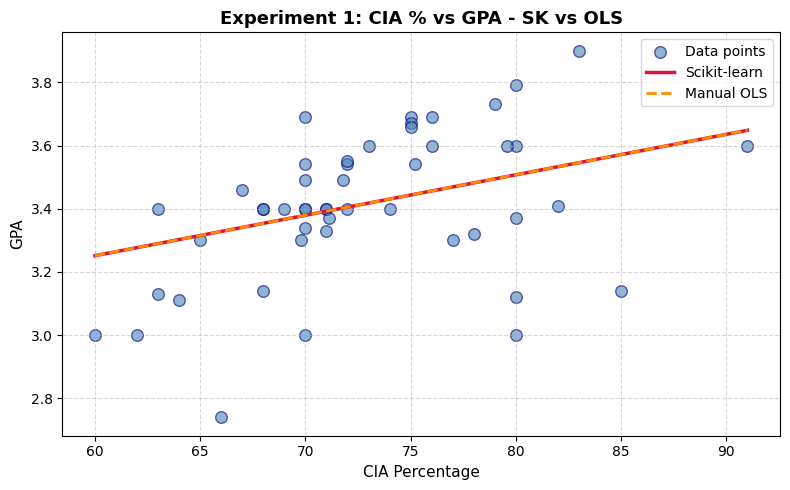

In [28]:
x_range1    = np.linspace(X1.min(), X1.max(), 200)
y_sk1_full  = slope_sk1  * x_range1 + intercept_sk1
y_ols1_full = slope_ols1 * x_range1 + intercept_ols1

plt.figure(figsize=(8, 5))
plt.scatter(df_clean['CIA_Percent'], df_clean['GPA'],
            color='steelblue', edgecolors='navy', alpha=0.6, s=70, label='Data points')
plt.plot(x_range1, y_sk1_full, color='crimson', linewidth=2.5,
         linestyle='-', label='Scikit-learn')
plt.plot(x_range1, y_ols1_full, color='darkorange', linewidth=2,
         linestyle='--', label='Manual OLS')
plt.title('Experiment 1: CIA % vs GPA - SK vs OLS', fontsize=13, fontweight='bold')
plt.xlabel('CIA Percentage', fontsize=11)
plt.ylabel('GPA', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Comparison - Experiment 2 (Attendance % to GPA)

In [29]:
print("Parameter Comparison - Experiment 2")
print("{:<15} {:>15} {:>15}".format("Parameter", "Scikit-learn", "Manual OLS"))
print("-" * 48)
print("{:<15} {:>15.6f} {:>15.6f}".format("Slope", slope_sk2, slope_ols2))
print("{:<15} {:>15.6f} {:>15.6f}".format("Intercept", intercept_sk2, intercept_ols2))

Parameter Comparison - Experiment 2
Parameter          Scikit-learn      Manual OLS
------------------------------------------------
Slope                  0.024410        0.024410
Intercept              1.140655        1.140655


In [30]:
comp_df2 = pd.DataFrame({
    'Attendance_Percent' : x2_test_flat,
    'Actual_GPA'         : Y2_test,
    'Pred_SK'            : np.round(Y2_pred_sk, 6),
    'Pred_OLS'           : np.round(Y2_pred_ols, 6),
    'Difference'         : np.round(np.abs(Y2_pred_sk - Y2_pred_ols), 10)
})
print(comp_df2.to_string(index=False))

 Attendance_Percent  Actual_GPA  Pred_SK  Pred_OLS  Difference
              100.0        3.49 3.581648  3.581648         0.0
               97.0        3.69 3.508418  3.508418         0.0
               90.0        2.74 3.337548  3.337548         0.0
               95.0        3.66 3.459598  3.459598         0.0
              100.0        3.11 3.581648  3.581648         0.0
               99.0        3.33 3.557238  3.557238         0.0
               93.0        3.00 3.410778  3.410778         0.0
               96.0        3.40 3.484008  3.484008         0.0
               95.0        3.60 3.459598  3.459598         0.0
               95.0        3.34 3.459598  3.459598         0.0


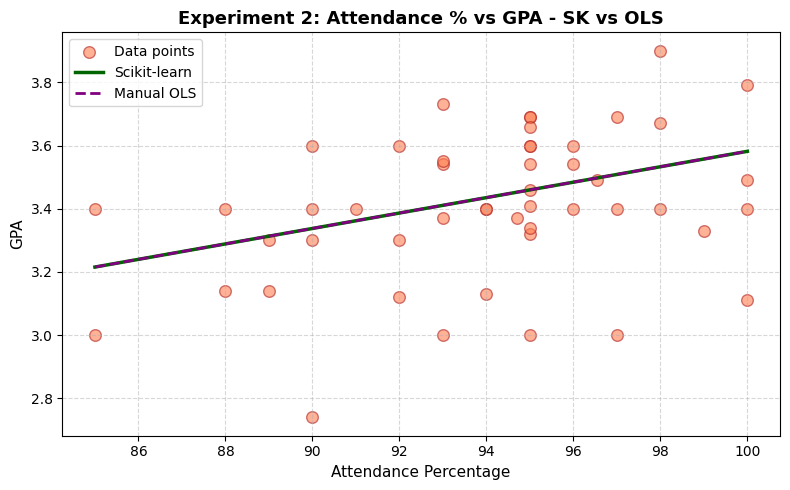

In [31]:
x_range2    = np.linspace(X2.min(), X2.max(), 200)
y_sk2_full  = slope_sk2  * x_range2 + intercept_sk2
y_ols2_full = slope_ols2 * x_range2 + intercept_ols2

plt.figure(figsize=(8, 5))
plt.scatter(df_clean['Attendance_Percent'], df_clean['GPA'],
            color='coral', edgecolors='firebrick', alpha=0.6, s=70, label='Data points')
plt.plot(x_range2, y_sk2_full, color='darkgreen', linewidth=2.5,
         linestyle='-', label='Scikit-learn')
plt.plot(x_range2, y_ols2_full, color='purple', linewidth=2,
         linestyle='--', label='Manual OLS')
plt.title('Experiment 2: Attendance % vs GPA - SK vs OLS', fontsize=13, fontweight='bold')
plt.xlabel('Attendance Percentage', fontsize=11)
plt.ylabel('GPA', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Observations

Parameters :The slope and intercept from both methods are identical.

Predictions : The difference between predictions from both methods is nearly zero (less than 1e-9).

Reason : Scikit-learn uses the same OLS minimisation internally so results will always match.

Experiment 1 (CIA %) : There is a mild positive relationship between CIA % and GPA.

Experiment 2 (Attendance %): The relationship between Attendance % and GPA is weaker and more scattered.

---
## Parameter Saving using Pickle

Saving the slope and intercept for both experiments to a file called `linear_regression_weights.pkl`.

### Save Parameters

In [32]:
model_params = {
    'experiment_1': {
        'independent_variable' : 'CIA_Percent',
        'dependent_variable'   : 'GPA',
        'slope_sklearn'        : slope_sk1,
        'intercept_sklearn'    : intercept_sk1,
        'slope_ols'            : slope_ols1,
        'intercept_ols'        : intercept_ols1
    },
    'experiment_2': {
        'independent_variable' : 'Attendance_Percent',
        'dependent_variable'   : 'GPA',
        'slope_sklearn'        : slope_sk2,
        'intercept_sklearn'    : intercept_sk2,
        'slope_ols'            : slope_ols2,
        'intercept_ols'        : intercept_ols2
    }
}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(model_params, f)

print("Parameters saved to linear_regression_weights.pkl")

for exp, params in model_params.items():
    print("\n", exp.upper())
    for k, v in params.items():
        print("  ", k, ":", v)

Parameters saved to linear_regression_weights.pkl

 EXPERIMENT_1
   independent_variable : CIA_Percent
   dependent_variable : GPA
   slope_sklearn : 0.01279967845914644
   intercept_sklearn : 2.483379907389372
   slope_ols : 0.012799678459146214
   intercept_ols : 2.4833799073893883

 EXPERIMENT_2
   independent_variable : Attendance_Percent
   dependent_variable : GPA
   slope_sklearn : 0.02440993165985645
   intercept_sklearn : 1.1406546355016682
   slope_ols : 0.024409931659849202
   intercept_ols : 1.140654635502346


### Load Parameters

In [33]:
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

print("Parameters loaded from pickle file")

for exp, params in loaded_params.items():
    print("\n", exp.upper())
    for k, v in params.items():
        print("  ", k, ":", v)

Parameters loaded from pickle file

 EXPERIMENT_1
   independent_variable : CIA_Percent
   dependent_variable : GPA
   slope_sklearn : 0.01279967845914644
   intercept_sklearn : 2.483379907389372
   slope_ols : 0.012799678459146214
   intercept_ols : 2.4833799073893883

 EXPERIMENT_2
   independent_variable : Attendance_Percent
   dependent_variable : GPA
   slope_sklearn : 0.02440993165985645
   intercept_sklearn : 1.1406546355016682
   slope_ols : 0.024409931659849202
   intercept_ols : 1.140654635502346


### Predict using Loaded Parameters

In [34]:
m1 = loaded_params['experiment_1']['slope_sklearn']
b1 = loaded_params['experiment_1']['intercept_sklearn']

print("Predictions using loaded parameters - Experiment 1")
print("Equation: GPA = {:.4f} * CIA% + {:.4f}".format(m1, b1))
print("{:>10}  {:>15}".format("CIA %", "Predicted GPA"))
print("-" * 28)
for cia in [60, 70, 75, 80, 85, 90]:
    print("{:>10}  {:>15.4f}".format(cia, m1 * cia + b1))

print()

m2 = loaded_params['experiment_2']['slope_sklearn']
b2 = loaded_params['experiment_2']['intercept_sklearn']

print("Predictions using loaded parameters - Experiment 2")
print("Equation: GPA = {:.4f} * Att% + {:.4f}".format(m2, b2))
print("{:>10}  {:>15}".format("Att %", "Predicted GPA"))
print("-" * 28)
for att in [75, 80, 85, 90, 95, 100]:
    print("{:>10}  {:>15.4f}".format(att, m2 * att + b2))

Predictions using loaded parameters - Experiment 1
Equation: GPA = 0.0128 * CIA% + 2.4834
     CIA %    Predicted GPA
----------------------------
        60           3.2514
        70           3.3794
        75           3.4434
        80           3.5074
        85           3.5714
        90           3.6354

Predictions using loaded parameters - Experiment 2
Equation: GPA = 0.0244 * Att% + 1.1407
     Att %    Predicted GPA
----------------------------
        75           2.9714
        80           3.0934
        85           3.2155
        90           3.3375
        95           3.4596
       100           3.5816


---
## Summary

Both Scikit-learn and the manual OLS method give identical slope and intercept values because they both solve the same least squares minimisation problem. The small differences in predictions (less than 1e-9) are just due to floating point precision.